#### Using GRACE mascon data to analyze Ocean Mass & Sea Level Budget. ###


Written by Dr. Felix Landerer and Munish Sikka

There are two main objectives for this example from GRACE-FO User handbook (Section 7.4.3). The first is to derive global ocean mass anomalies from GRACE mascon ocean bottom pressure (OBP) data. The second objective involves determining anomalies in the global sea level budget and estimate the change in ocean volume caused by thermal expansion.

References: 

1) GRACE-FO L3 Handbook: https://podaac-tools.jpl.nasa.gov/drive/files/allData/gracefo/docs/GRACE-FO_L3_Handbook_JPL.pdf

2) https://www.earthdatascience.org/courses/use-data-open-source-python/hierarchical-data-formats-hdf/subset-netcdf4-climate-data-spatially-aoi/

Version 1.0 [May-2026]

In [1]:
import requests
import time
from netCDF4 import Dataset, date2index
from datetime import datetime, date

import xarray as xr

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import pandas as pd 

import warnings
import os


import sys
import os.path
import subprocess
import netCDF4
import numpy
import datetime
import math
import csv

from dateutil import parser
from datetime import datetime as dt
from datetime import date
from datetime import datetime
import time
from scipy.interpolate import interp1d
#import s3fs
import fsspec
import urllib
import statsmodels.api
import warnings

import grace_user_functions as grace_func

Step 1: Read the dataset from local dir or establish cloud connection to read GRACE mascon dataset, sea mean dataset and thermosteric dataset

Read the GRACE mascon data as xarray; We need to update the filename as its updated every month with additional month added in the dataset.

Select the time period for which we wish to plot the monthly data.
Typical data latency is less than 60 days.

In [2]:
start_date = "2002-04-01"
end_date = "2025-10-31"
file_access_type = 'local'
climatology_start_year = 2005
climatology_end_year = 2010
#file_access_type = 'cloud'

# PO.DAAC's 'short name' is an identifier for the dataset
ShortName_mass = 'TELLUS_GRAC-GRFO_MASCON_CRI_GRID_RL06.1_V3' #GOMA
ShortName_steric = 'local'       # for cloud: 'HOMAGE_STERIC_OHC_TIME_SERIES_v01' #GMSSL
ShortName_seamean_doc = 'local'  # for cloud: 'MERGED_TP_J1_OSTM_OST_GMSL_ASCII_V51' #GMSL ; local updated to v5.2
grace_filename='GRCTellus.JPL.200204_202510.GLO.RL06.3M.MSCNv04CRI.nc'
local_seamean_filename = 'GMSL_TPJAOS_5.2.txt'
local_steric_filename = 'SIO_steric_ohc_time_series_20040116_20250717_v01.nc'

# download the GRACE mascon dataset and use the absolute path in next line where it is kept in local file system
full_filename = 'GRACE_RESOURCES/' + grace_filename
full_filename_GMSL = 'GRACE_RESOURCES/' + local_seamean_filename
full_filename_GMSSL = 'GRACE_RESOURCES/' + local_steric_filename

if file_access_type.lower() == 'local':
    print("Reading GRACE mascon dataset from local disk")
    try:
        dataset = xr.open_dataset((full_filename))
    except FileNotFoundError:
        print('Error: The file does not exist.')
elif file_access_type.lower() == "cloud":
    print("Reading GRACE mascon dataset from PODAAC Cloud")
    import s3fs
    dataset=grace_func.read_grace_dataset(ShortName_mass,grace_filename)	
else:
    print("Unknown file access type.")

sea_mean_vals,sea_time_vec=grace_func.read_sea_mean_doc(ShortName_seamean_doc,full_filename_GMSL)

steric_data,steric_time=grace_func.read_thermosteric_data(ShortName_steric,start_date,end_date,full_filename_GMSSL) # read thermosteric values.

Reading GRACE mascon dataset from local disk


In [3]:
#read GRACE data from mascon dataset for the desired time period. 
lwe_thickness_xarray = dataset["lwe_thickness"].sel(
    time=slice(start_date, end_date))

# extract lat, lon and grid array from xarray dataset
lwe_thickness=lwe_thickness_xarray.data
print(lwe_thickness.shape)

(250, 360, 720)


1.1 Read land-sea mask from the desired mask .nc file

In [4]:
# read land mask from mascon dataset
land_mask=dataset["land_mask"].to_numpy()
ocean_mask=abs(1-land_mask)

1.2 Open TN12 doc and read Global Mean Ocean Mass 
(column name: mean atm mass over global ocean (mmH2O) [Note: the underlying land-sea mask is the JPL-CRI-Mascon mask SEA_MASK.CRIv01.nc] )

In [5]:
TN12_url = "https://archive.podaac.earthdata.nasa.gov/podaac-ops-cumulus-docs/gracefo/open/docs/TN-12_glob_atm_oceanMEAN_GAD_RL06.txt"
TN12_data = grace_func.read_TN12_url(TN12_url)

1.3 Convert Grace time (from TN12 doc) to yearfraction.

In [6]:
# Convert user defined start and end date to yearfrac
dt_obj_start = parser.parse(start_date)
dt_obj_end = parser.parse(end_date)

start_datetime=grace_func.toYearFraction(dt_obj_start)
end_datetime=grace_func.toYearFraction(dt_obj_end)

#read TN12 for this selective time period
TN12_time_coords1={'year':TN12_data['year']}
# TN12 var: 'mass_over_ocean_JPLmask'
temp_TN12=xr.DataArray(data=TN12_data['mass_over_ocean_JPLmask'], coords=TN12_time_coords1, dims='year')
TN12_selected_vals=temp_TN12.sel(year=slice(start_datetime,end_datetime)).values

# timevar: 'year'
temp_time_vec=xr.DataArray(data=TN12_data['year'], coords=TN12_time_coords1, dims='year')
time_vec=temp_time_vec.sel(year=slice(start_datetime,end_datetime)).values

Convert Grace mascon t-mid and timebouds to yearfrac

In [7]:
# 1. Slice the data 
time_mascon = dataset["time"].sel(time=slice(start_date, end_date)).data
mascon_timebounds = dataset["time_bounds"].sel(time=slice(start_date, end_date)).data
# Convert mid-times to year fraction
time_GRACE_yearfrac = np.array([
    grace_func.toYearFraction(parser.parse(str(t)))
    for t in time_mascon
])

# Convert time bounds to year fraction
time_bounds_yearfrac = np.array([
    [
        grace_func.toYearFraction(parser.parse(str(tb[0]))),
        grace_func.toYearFraction(parser.parse(str(tb[1])))
    ]
    for tb in mascon_timebounds
])

Step 2: Calculate the grid area by calling area weights function; read latitude from mascon file and apply area weights on a lat/lon matrix.

2.1     Multiply area weights with mask so we have masked index. 


In [8]:
# 1. Calculate and Prepare Area Weights
# Transpose directly into a (Lat, 1) column vector to enable broadcasting
area_weights = grace_func.area(dataset.lat.data)[:, np.newaxis]

# 2. Create the Weight Matrix
masked_area_matrix = area_weights * ocean_mask
masked_area_sum = np.nansum(masked_area_matrix)

# 3. Calculate Timeseries
weighted_sum = np.nansum(lwe_thickness * masked_area_matrix, axis=(1, 2))
timeseries_GRACE = weighted_sum / masked_area_sum
timeseries_GMOM_A = (timeseries_GRACE * 10) - TN12_selected_vals


2.2 Interpolate thermosteric data to Grace mascon timesteps

In [9]:
arr1_interp = interp1d(steric_time,steric_data,bounds_error=False)
GMSSL_GRACE_timestep = arr1_interp(time_GRACE_yearfrac) # interpolated dataset

2.3 Select data for desired time period

Note: time field is already in yearfrac

In [10]:
sea_mean_coords={'year_fraction':sea_time_vec}
# creating a xArray object and then using slice to extarct desired time period data from xarray
temp_sea_data=xr.DataArray(data=sea_mean_vals, coords=sea_mean_coords, dims='year_fraction')
sea_selected_vals=temp_sea_data.sel(year_fraction=slice(start_datetime,end_datetime)).values

temp_time_data=xr.DataArray(data=sea_time_vec, coords=sea_mean_coords, dims='year_fraction')
sea_selected_timevals=temp_time_data.sel(year_fraction=slice(start_datetime,end_datetime)).values

2.4 Using Grace mascon time_bounds, compute sea mean for each GRACE timestep 

In [11]:
# Check which sea timestamps fall between the start [:, 0] and end [:, 1] of each GRACE month
mask = (sea_selected_timevals[np.newaxis, :] >= time_bounds_yearfrac[:, 0, np.newaxis]) & \
       (sea_selected_timevals[np.newaxis, :] <= time_bounds_yearfrac[:, 1, np.newaxis])

# 2. Use the mask to calculate averages
# We use np.where to replace False with NaN so we can use nanmean
masked_timestamps = np.where(mask, sea_selected_timevals, np.nan)
masked_values = np.where(mask, sea_selected_vals, np.nan)

# 3. Compute the mean along axis 1 (the sea data axis), 
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    sea_mean_timestamps = np.nanmean(masked_timestamps, axis=1)
    sea_mean_data = np.nanmean(masked_values, axis=1)

2.5 Interpolate sea mean data to GRACE timestamps

In [12]:
# Create the interpolation function 
# We use fill_value=np.nan to handle timestamps outside the range automatically
arr2_interp = interp1d(sea_mean_timestamps, sea_mean_data, bounds_error=False, fill_value=np.nan)

# Calculate the mean of the start and end bounds for every row
selected_midpoints = np.mean(time_bounds_yearfrac, axis=1)

# Apply the interpolation function
GMSL_GRACE_timestep = arr2_interp(selected_midpoints)


Step 3: Plot monthly timeseries for three datasets

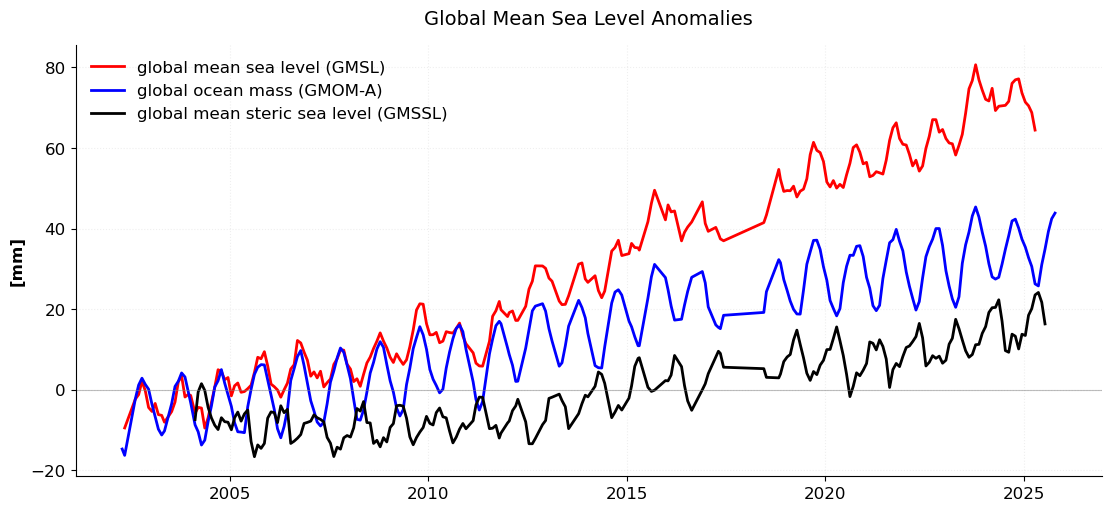

In [13]:
#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/
#set x axis labels as alternative years
plot_title_str = 'Global Mean Sea Level Anomalies'
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(time_vec, GMSL_GRACE_timestep,color='red', label='global mean sea level (GMSL)',lw=2)
ax.plot(time_vec, timeseries_GMOM_A, color='blue', label='global ocean mass (GMOM-A)',lw=2)
ax.plot(time_vec, GMSSL_GRACE_timestep,color='black', label='global mean steric sea level (GMSSL)',lw=2)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('[mm]', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)

Note: There is an offset in the datasets; Compute anomalies by removing mean of (2005 to 2010) for each dataset from its magnitude

In [14]:
idx_GRACE= (time_vec >= climatology_start_year)*(time_vec <= climatology_end_year)

mean_GMSL=np.mean(GMSL_GRACE_timestep[idx_GRACE])

mean_GMOM_A=np.mean(timeseries_GMOM_A[idx_GRACE])

mean_GMSSL=np.mean(GMSSL_GRACE_timestep[idx_GRACE])

#subtract this mean 
GMOM_A_anomaly=timeseries_GMOM_A-mean_GMOM_A
GMSL_anomaly=GMSL_GRACE_timestep-mean_GMSL
GMSSL_anomaly=GMSSL_GRACE_timestep-mean_GMSSL

3.1 Plot the computed anomalies

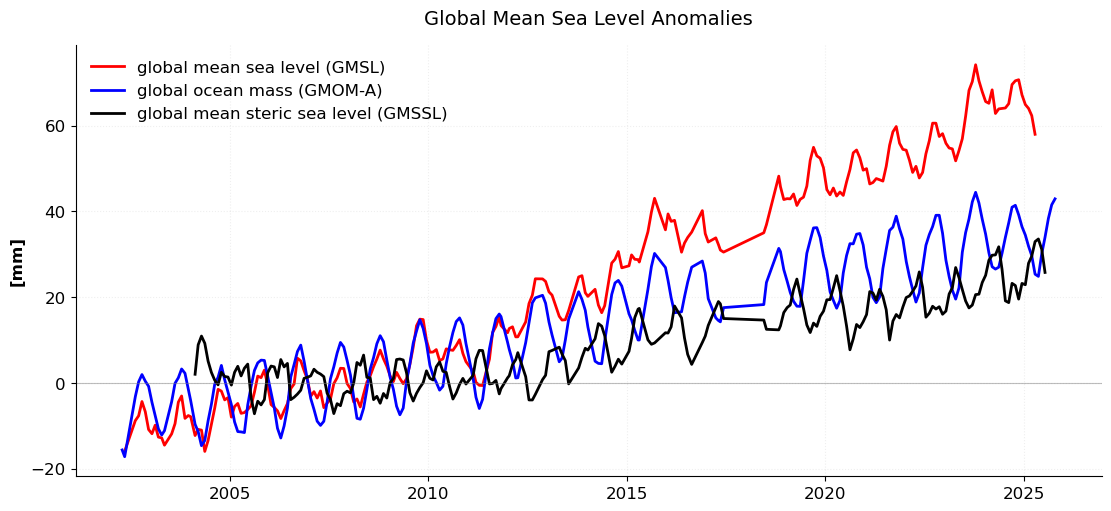

In [15]:
# 2005-2010 mean subtracted
# plot monthly timeseries (#ref: https://unidata.github.io/python-training/workshop/Time_Series/basic-time-series-plotting/)
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(time_vec, GMSL_anomaly,color='red', label='global mean sea level (GMSL)',lw=2)
ax.plot(time_vec, GMOM_A_anomaly, color='blue', label='global ocean mass (GMOM-A)',lw=2)
ax.plot(time_vec, GMSSL_anomaly,color='black', label='global mean steric sea level (GMSSL)',lw=2)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('[mm]', fontweight='bold')
ax.set_title(plot_title_str, fontsize=14, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)

3.2 Extract from Handbook: 

"Approach: The approach to derive global ocean mass anomalies involves removing the effects of atmospheric pressure from bottom pressure, and then adjusting for the difference of ocean density versus freshwater density. The resulting ocean mass anomalies are then subtracted from the sea surface height anomalies from altimetry measurements in order to assess ocean height changes caused by thermal expansion. Methods used in this use case follow those described by Llovel et al. (2015)."

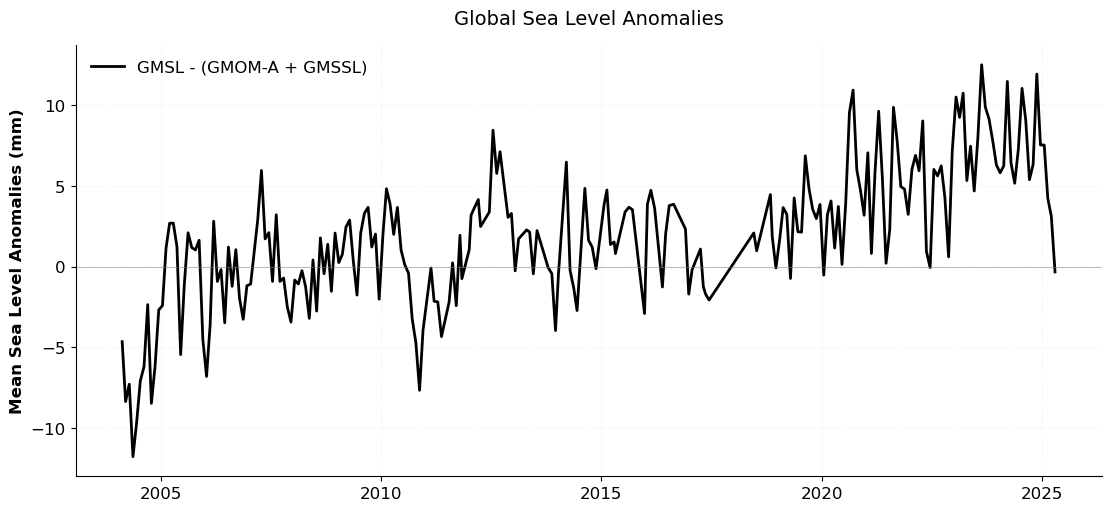

In [16]:
# diff of sea minus (MASS + thermosteric)
diff_mass=GMSL_anomaly-(GMOM_A_anomaly+GMSSL_anomaly) # to be smoothed
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
ax.plot(time_vec[:], diff_mass[:],color='black', label='GMSL - (GMOM-A + GMSSL)',lw=2)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Mean Sea Level Anomalies (mm)', fontweight='bold')
ax.set_title('Global Sea Level Anomalies', fontsize=14, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)

3.3 Smoothing: Lowess model from statsmodel.api module

In [17]:
#https://www.statsmodels.org/dev/generated/statsmodels.nonparametric.smoothers_lowess.lowess.html
frac= 11/(diff_mass.size) #11 month divided by total monthly entries for frac parameter
# frac: Between 0 and 1. The fraction of the data used when estimating each y-value.
print(f'Using frac value: {frac}')
diff_mass_smoothed=statsmodels.nonparametric.smoothers_lowess.lowess(diff_mass,time_vec,frac)

Using frac value: 0.044


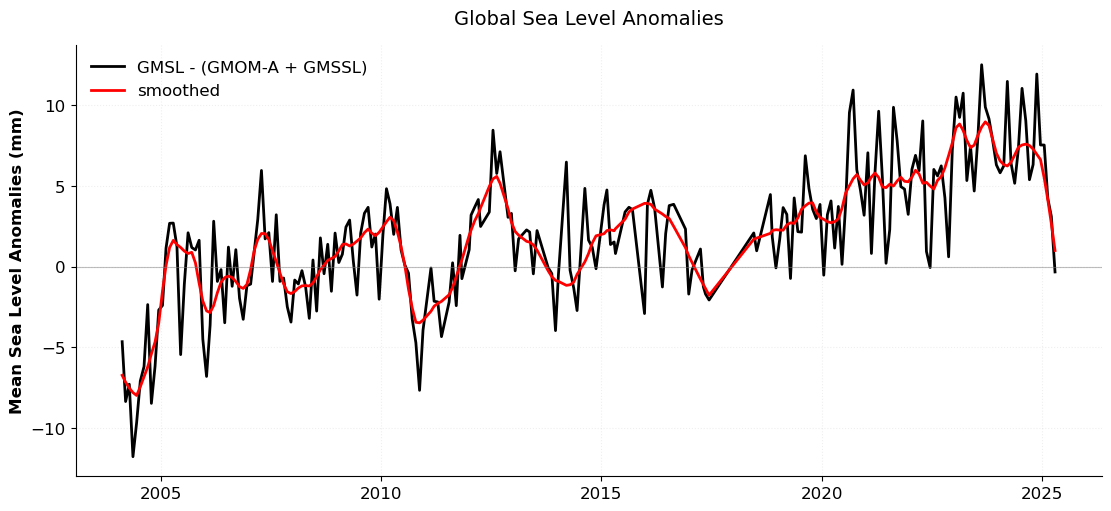

In [18]:
#Plot with smoothed version
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)

ax.plot(time_vec, diff_mass,color='black', label='GMSL - (GMOM-A + GMSSL)',lw=2)
ax.plot(diff_mass_smoothed[:,0], diff_mass_smoothed[:,1],color='red', label='smoothed',lw=2)
ax.axhline(y=0.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.5)
ax.set_ylabel('Mean Sea Level Anomalies (mm)', fontweight='bold')
ax.set_title('Global Sea Level Anomalies', fontsize=14, pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2, linestyle=':')
ax.legend(loc='best', frameon=False)